In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%matplotlib inline
plt.style.use("ggplot")

In [2]:
!pip install -U kaleido

In [3]:
df = pd.read_csv("weather_hourly.csv", skiprows=3)

In [4]:
df.head()

,time,temperature_2m (Â°C),apparent_temperature (Â°C),relative_humidity_2m (%),precipitation (mm),weather_code (wmo code),surface_pressure (hPa),wind_speed_10m (km/h),cloud_cover (%)
0,2025-01-01T00:00,18.5,19.2,87,0.0,0,1012.5,9.4,0
1,2025-01-01T01:00,18.4,19.4,89,0.0,0,1012.9,8.3,0
2,2025-01-01T02:00,17.9,18.9,92,0.0,0,1013.5,8.4,0
3,2025-01-01T03:00,19.3,20.5,84,0.0,0,1014.4,7.2,0
4,2025-01-01T04:00,22.5,24.2,71,0.0,0,1015.1,5.2,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13368 entries, 0 to 13367
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time                        13368 non-null  str    
 1   temperature_2m (Â°C)        13368 non-null  float64
 2   apparent_temperature (Â°C)  13368 non-null  float64
 3   relative_humidity_2m (%)    13368 non-null  int64  
 4   precipitation (mm)          13368 non-null  float64
 5   weather_code (wmo code)     13368 non-null  int64  
 6   surface_pressure (hPa)      13368 non-null  float64
 7   wind_speed_10m (km/h)       13368 non-null  float64
 8   cloud_cover (%)             13368 non-null  int64  
dtypes: float64(5), int64(3), str(1)
memory usage: 1.1 MB


In [6]:
print("Rows and Columns :"), df.shape

Rows and Columns :


(None, (13368, 9))

In [7]:
df.isnull().sum()

time                          0
temperature_2m (Â°C)          0
apparent_temperature (Â°C)    0
relative_humidity_2m (%)      0
precipitation (mm)            0
weather_code (wmo code)       0
surface_pressure (hPa)        0
wind_speed_10m (km/h)         0
cloud_cover (%)               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,temperature_2m (Â°C),apparent_temperature (Â°C),relative_humidity_2m (%),precipitation (mm),weather_code (wmo code),surface_pressure (hPa),wind_speed_10m (km/h),cloud_cover (%)
count,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000
mean,27.949005,30.374132,62.485189,0.144270,9.573384,1006.720033,10.214602,34.291667
std,4.881539,5.949559,23.700184,0.692926,19.860940,4.793205,4.495357,42.081186
min,13.000000,11.300000,6.000000,0.000000,0.000000,991.800000,0.000000,0.000000
25%,25.200000,26.975000,45.000000,0.000000,0.000000,1003.300000,7.300000,0.000000
50%,27.900000,31.500000,66.000000,0.000000,0.000000,1006.700000,9.700000,7.000000
75%,30.700000,34.300000,82.000000,0.000000,3.000000,1010.600000,12.500000,89.000000
max,43.200000,45.400000,100.000000,18.400000,65.000000,1018.500000,29.400000,100.000000


In [10]:
df.columns = [
    "DateTime",
    "Temperature",
    "Apparent_Temperature",
    "Humidity",
    "Precipitation",
    "Weather_Code",
    "Surface_Pressure",
    "Wind_Speed",
    "Cloud_Cover"
]

In [11]:
df.head()

,DateTime,Temperature,Apparent_Temperature,Humidity,Precipitation,Weather_Code,Surface_Pressure,Wind_Speed,Cloud_Cover
0,2025-01-01T00:00,18.5,19.2,87,0.0,0,1012.5,9.4,0
1,2025-01-01T01:00,18.4,19.4,89,0.0,0,1012.9,8.3,0
2,2025-01-01T02:00,17.9,18.9,92,0.0,0,1013.5,8.4,0
3,2025-01-01T03:00,19.3,20.5,84,0.0,0,1014.4,7.2,0
4,2025-01-01T04:00,22.5,24.2,71,0.0,0,1015.1,5.2,0


In [12]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [13]:
df.dtypes

DateTime                datetime64[us]
Temperature                    float64
Apparent_Temperature           float64
Humidity                         int64
Precipitation                  float64
Weather_Code                     int64
Surface_Pressure               float64
Wind_Speed                     float64
Cloud_Cover                      int64
dtype: object

In [14]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Month_Name"] = df["DateTime"].dt.month_name()
df["Day"] = df["DateTime"].dt.day
df["Day_Name"] = df["DateTime"].dt.day_name()
df["Hour"] = df["DateTime"].dt.hour

In [15]:
df["Weekend"] = df["Day_Name"].isin(["Saturday","Sunday"])

In [16]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else: 
        return "Post-Monsoon"

df["Season"] = df["Month"].apply(get_season)        

In [17]:
df["Rain"] = df["Precipitation"].apply(
    lambda x: "Yes" if x > 0 else "No"
)

In [18]:
df.head()

,DateTime,Temperature,Apparent_Temperature,Humidity,Precipitation,Weather_Code,Surface_Pressure,Wind_Speed,Cloud_Cover,Year,Month,Month_Name,Day,Day_Name,Hour,Weekend,Season,Rain
0,2025-01-01 00:00:00,18.5,19.2,87,0.0,0,1012.5,9.4,0,2025,1,January,1,Wednesday,0,False,Winter,No
1,2025-01-01 01:00:00,18.4,19.4,89,0.0,0,1012.9,8.3,0,2025,1,January,1,Wednesday,1,False,Winter,No
2,2025-01-01 02:00:00,17.9,18.9,92,0.0,0,1013.5,8.4,0,2025,1,January,1,Wednesday,2,False,Winter,No
3,2025-01-01 03:00:00,19.3,20.5,84,0.0,0,1014.4,7.2,0,2025,1,January,1,Wednesday,3,False,Winter,No
4,2025-01-01 04:00:00,22.5,24.2,71,0.0,0,1015.1,5.2,0,2025,1,January,1,Wednesday,4,False,Winter,No


In [19]:
df.to_csv("cleaned_weather_hourly.csv", index=False)

In [20]:
import os
print(os.getcwd())

C:\Users\devya\Documents


In [21]:
df.shape

(13368, 18)

In [22]:
df.head()

,DateTime,Temperature,Apparent_Temperature,Humidity,Precipitation,Weather_Code,Surface_Pressure,Wind_Speed,Cloud_Cover,Year,Month,Month_Name,Day,Day_Name,Hour,Weekend,Season,Rain
0,2025-01-01 00:00:00,18.5,19.2,87,0.0,0,1012.5,9.4,0,2025,1,January,1,Wednesday,0,False,Winter,No
1,2025-01-01 01:00:00,18.4,19.4,89,0.0,0,1012.9,8.3,0,2025,1,January,1,Wednesday,1,False,Winter,No
2,2025-01-01 02:00:00,17.9,18.9,92,0.0,0,1013.5,8.4,0,2025,1,January,1,Wednesday,2,False,Winter,No
3,2025-01-01 03:00:00,19.3,20.5,84,0.0,0,1014.4,7.2,0,2025,1,January,1,Wednesday,3,False,Winter,No
4,2025-01-01 04:00:00,22.5,24.2,71,0.0,0,1015.1,5.2,0,2025,1,January,1,Wednesday,4,False,Winter,No


In [23]:
df["Rain"].value_counts()

Rain
No     11122
Yes     2246
Name: count, dtype: int64

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13368 entries, 0 to 13367
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DateTime              13368 non-null  datetime64[us]
 1   Temperature           13368 non-null  float64       
 2   Apparent_Temperature  13368 non-null  float64       
 3   Humidity              13368 non-null  int64         
 4   Precipitation         13368 non-null  float64       
 5   Weather_Code          13368 non-null  int64         
 6   Surface_Pressure      13368 non-null  float64       
 7   Wind_Speed            13368 non-null  float64       
 8   Cloud_Cover           13368 non-null  int64         
 9   Year                  13368 non-null  int32         
 10  Month                 13368 non-null  int32         
 11  Month_Name            13368 non-null  str           
 12  Day                   13368 non-null  int32         
 13  Day_Name              13368

In [25]:
df.describe()

,DateTime,Temperature,Apparent_Temperature,Humidity,Precipitation,Weather_Code,Surface_Pressure,Wind_Speed,Cloud_Cover,Year,Month,Day,Hour
count,13368,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000,13368.000000
mean,2025-10-06 11:30:00,27.949005,30.374132,62.485189,0.144270,9.573384,1006.720033,10.214602,34.291667,2025.344704,5.554758,15.490126,11.500000
min,2025-01-01 00:00:00,13.000000,11.300000,6.000000,0.000000,0.000000,991.800000,0.000000,0.000000,2025.000000,1.000000,1.000000,0.000000
25%,2025-05-20 05:45:00,25.200000,26.975000,45.000000,0.000000,0.000000,1003.300000,7.300000,0.000000,2025.000000,3.000000,8.000000,5.750000
50%,2025-10-06 11:30:00,27.900000,31.500000,66.000000,0.000000,0.000000,1006.700000,9.700000,7.000000,2025.000000,5.000000,15.000000,11.500000
75%,2026-02-22 17:15:00,30.700000,34.300000,82.000000,0.000000,3.000000,1010.600000,12.500000,89.000000,2026.000000,8.000000,23.000000,17.250000
max,2026-07-11 23:00:00,43.200000,45.400000,100.000000,18.400000,65.000000,1018.500000,29.400000,100.000000,2026.000000,12.000000,31.000000,23.000000
std,NaN,4.881539,5.949559,23.700184,0.692926,19.860940,4.793205,4.495357,42.081186,0.475289,3.280438,8.804522,6.922445


In [26]:
total_records = len(df)
print("Total Records:", total_records)

avg_temperature = round(df["Temperature"].mean(), 2)
print("Average Temperature:", avg_temperature, "°C")

avg_humidity = round(df["Humidity"].mean(), 2)
print("Average Humidity:", avg_humidity, "%")

total_rainfall = round(df["Precipitation"].sum(), 2)
print("Total Rainfall:", total_rainfall, "mm")

avg_wind_speed = round(df["Wind_Speed"].mean(), 2)
print("Average Wind Speed:", avg_wind_speed, "km/h")

avg_surface_pressure = round(df["Surface_Pressure"].mean(), 2)
print("Average Surface Pressure:", avg_surface_pressure, "hPa")

Total Records: 13368
Average Temperature: 27.95 °C
Average Humidity: 62.49 %
Total Rainfall: 1928.6 mm
Average Wind Speed: 10.21 km/h
Average Surface Pressure: 1006.72 hPa


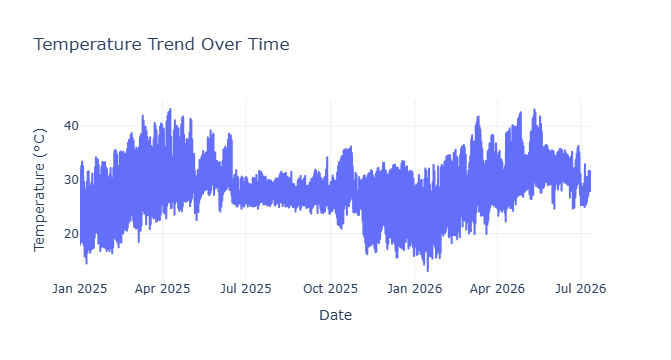

In [27]:
fig = px.line(
    df,
    x="DateTime",
    y="Temperature",
    title="Temperature Trend Over Time"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Temperature (°C)",
    template="plotly_white"
)
fig.write_image("temp_trend.png", scale=2)
fig.show()

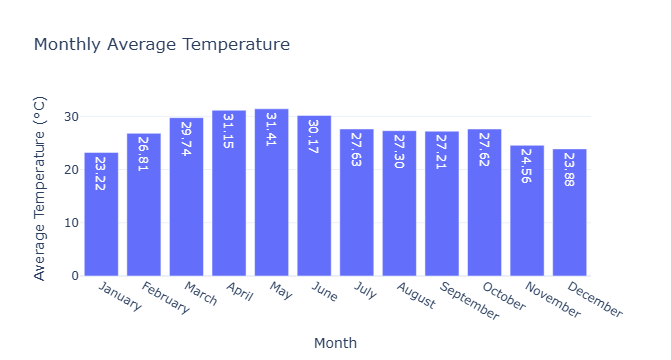

In [28]:
monthly_temp = (
    df.groupby("Month_Name")["Temperature"]
    .mean()
    .reset_index()
)

month_order = [
    "January", "February", "March", "April", "May", "June", "July",
    "August", "September", "October", "November", "December"
]

monthly_temp["Month_Name"] = pd.Categorical(
    monthly_temp["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_temp = monthly_temp.sort_values("Month_Name")

fig = px.bar(
    monthly_temp,
    x="Month_Name",
    y="Temperature",
    text_auto=".2f",
    title="Monthly Average Temperature"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Average Temperature (°C)"
)
fig.write_image("monthly_avg_temp.png", scale=2)
fig.show()

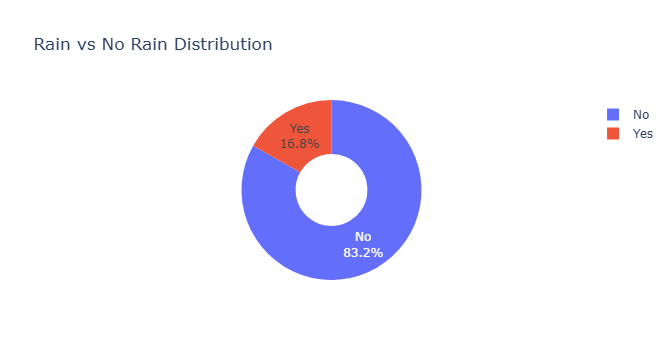

In [29]:
rain_counts = df["Rain"].value_counts().reset_index()
rain_counts.columns = ["Rain", "Count"]

fig = px.pie(
    rain_counts,
    names="Rain",
    values="Count",
    hole=0.4,
    title="Rain vs No Rain Distribution"
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.write_image("rain_distribution.png", scale=2)
fig.show()

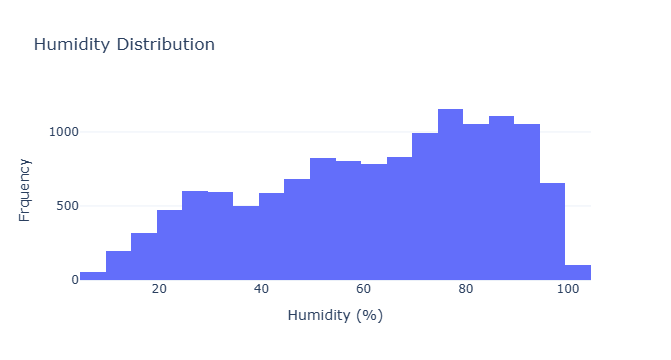

In [30]:
fig = px.histogram(
    df,
    x="Humidity",
    nbins=30,
    title="Humidity Distribution"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Humidity (%)",
    yaxis_title="Frquency"
)
fig.write_image("humidity_dist.png", scale=2)
fig.show()

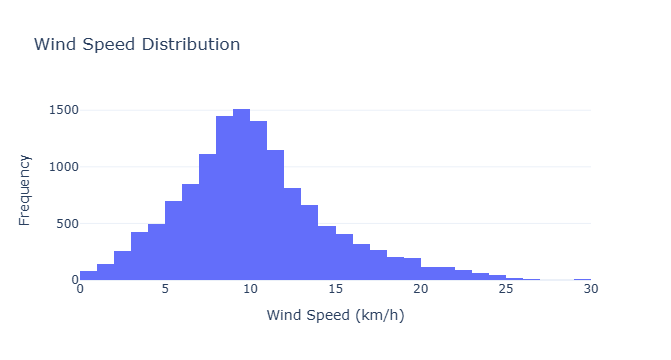

In [31]:
fig = px.histogram(
    df,
    x="Wind_Speed",
    nbins=30,
    title="Wind Speed Distribution"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Wind Speed (km/h)",
    yaxis_title="Frequency"
)
fig.write_image("wind_speed_dist.png", scale=2)
fig.show()

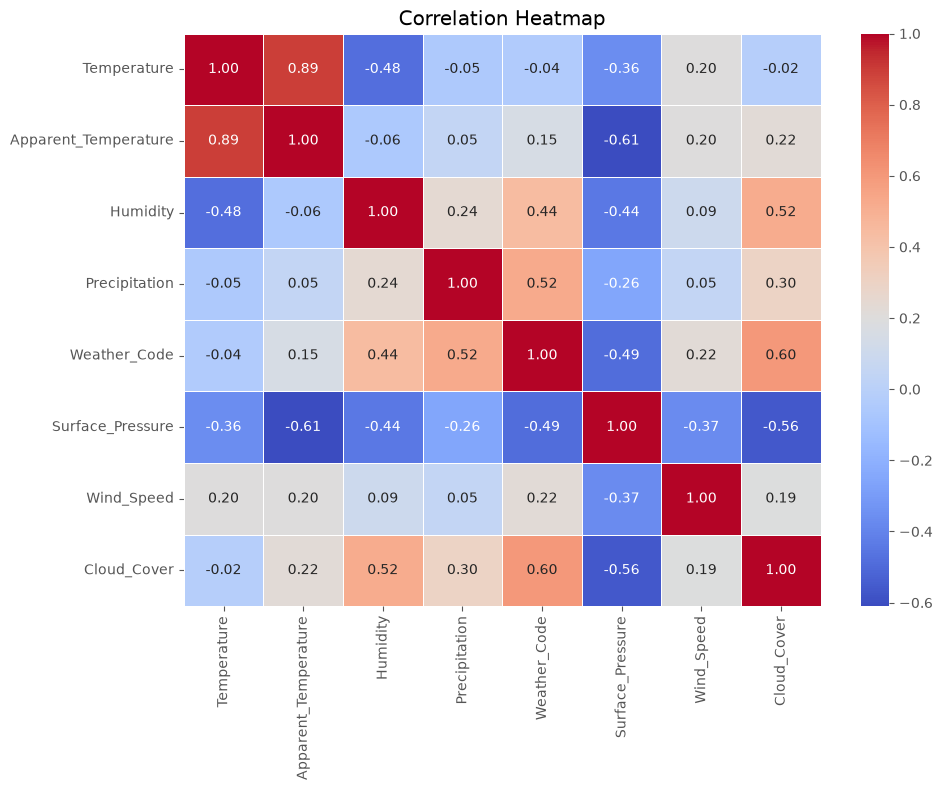

In [32]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)    

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

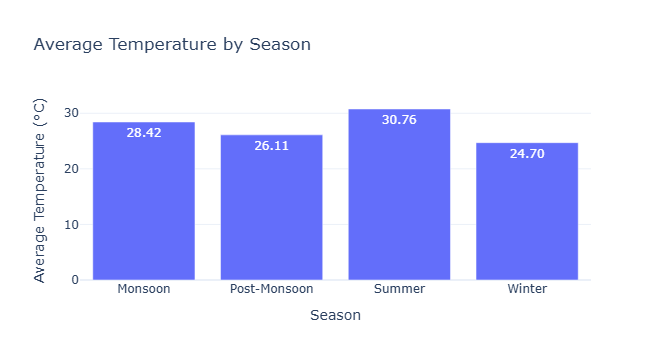

In [33]:
season_temp = (
    df.groupby("Season")["Temperature"]
    .mean()
    .reset_index()
)

fig = px.bar(
    season_temp,
    x="Season",
    y="Temperature",
    text_auto=".2f",
    title="Average Temperature by Season"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Season",
    yaxis_title="Average Temperature (°C)"
)
fig.write_image("season_temp.png", scale=2)
fig.show()

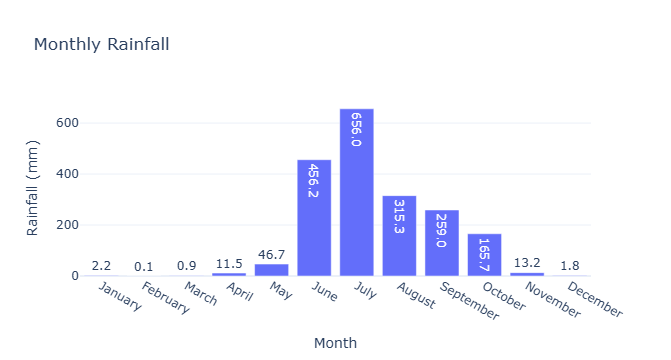

In [34]:
monthly_rain = (
    df.groupby("Month")["Precipitation"]
      .sum()
      .reset_index()
)

month_names = {
    1:"January",2:"February",3:"March",4:"April",
    5:"May",6:"June",7:"July",8:"August",
    9:"September",10:"October",11:"November",12:"December"
}

monthly_rain["Month_Name"] = monthly_rain["Month"].map(month_names)

fig = px.bar(
    monthly_rain,
    x="Month_Name",
    y="Precipitation",
    text_auto=".1f",
    title="Monthly Rainfall"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Rainfall (mm)"
)
fig.write_image("monthly_rainfall.png", scale=2)
fig.show()

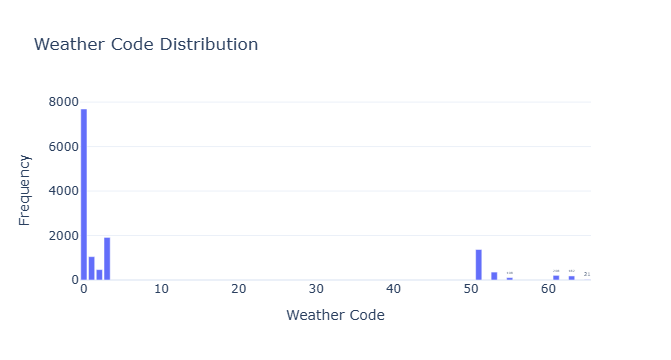

In [35]:
weather_code = (
    df["Weather_Code"]
    .value_counts()
    .reset_index()
)

weather_code.columns = ["Weather_Code", "Count"]

fig = px.bar(
    weather_code,
    x="Weather_Code",
    y="Count",
    title="Weather Code Distribution",
    text_auto=True
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Weather Code",
    yaxis_title="Frequency"
)
fig.write_image("weather_code_dist.png", scale=2)
fig.show()

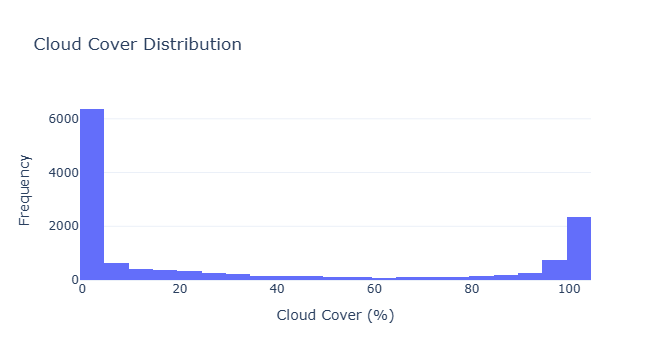

In [36]:
fig = px.histogram(
    df,
    x="Cloud_Cover",
    nbins=30,
    title="Cloud Cover Distribution"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Cloud Cover (%)",
    yaxis_title="Frequency"
)
fig.write_image("cloud_cover_dist.png", scale=2)
fig.show()

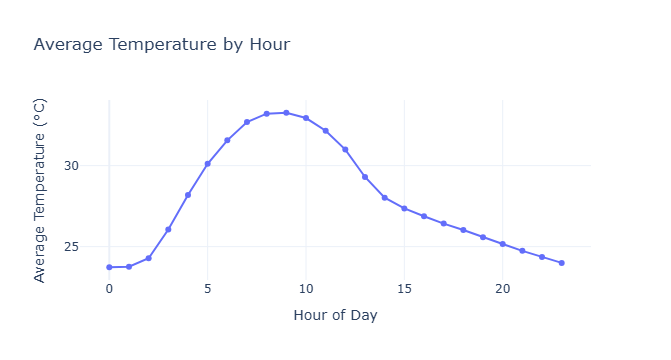

In [37]:
hourly_temp = (
    df.groupby("Hour")["Temperature"]
    .mean()
    .reset_index()
)

fig = px.line(
    hourly_temp,
    x="Hour",
    y="Temperature",
    markers=True,
    title="Average Temperature by Hour"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Hour of Day",
    yaxis_title="Average Temperature (°C)"
)
fig.write_image("hourly_temp.png", scale=2)
fig.show()

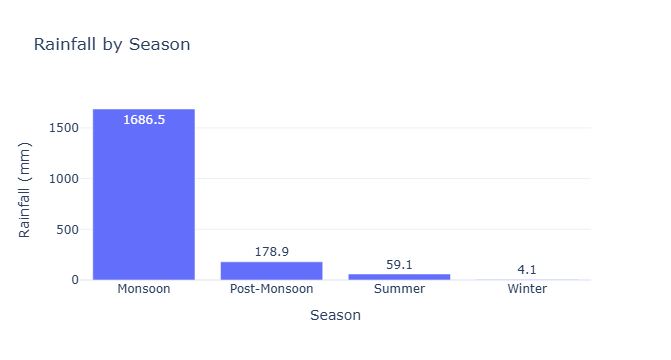

In [38]:
season_rain = (
    df.groupby("Season")["Precipitation"]
    .sum()
    .reset_index()
)

fig = px.bar(
    season_rain,
    x="Season",
    y="Precipitation",
    text_auto=".1f",
    title="Rainfall by Season"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Season",
    yaxis_title="Rainfall (mm)"
)
fig.write_image("season_rain.png", scale=2)
fig.show()

In [39]:
X = df[[
    "Temperature",
    "Apparent_Temperature",
    "Humidity",
    "Surface_Pressure",
    "Wind_Speed",
    "Cloud_Cover",
    
]]

y = df["Rain"]

In [40]:
le = LabelEncoder()
y = le.fit_transform(y)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Training Target :", y_test.shape)

Training Features : (10694, 6)
Testing Features : (2674, 6)
Training Target : (10694,)
Training Target : (2674,)


In [43]:
# Train Model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    )

lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2),"%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 88.03 %

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      2225
           1       0.63      0.68      0.66       449

    accuracy                           0.88      2674
   macro avg       0.78      0.80      0.79      2674
weighted avg       0.88      0.88      0.88      2674


Confusion Matrix:

[[2048  177]
 [ 143  306]]


In [44]:
#Train Model
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

#Prediction
y_pred_dt = dt_model.predict(X_test)

#Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")

#Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 87.28 %

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      2225
           1       0.61      0.66      0.64       449

    accuracy                           0.87      2674
   macro avg       0.77      0.79      0.78      2674
weighted avg       0.88      0.87      0.87      2674


Confusion Matrix:

[[2036  189]
 [ 151  298]]


In [45]:
#Train Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

#Prediction
y_pred_rf = rf_model.predict(X_test)

#Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy*100,2),"%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 91.1 %

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2225
           1       0.76      0.69      0.72       449

    accuracy                           0.91      2674
   macro avg       0.85      0.82      0.83      2674
weighted avg       0.91      0.91      0.91      2674


Confusion Matrix:

[[2128   97]
 [ 141  308]]


In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score
comparison = ({
    "Model":[
        "Logistics Regression",
        "Decision Tree",
        "Random Forest",
    ],
    "Accuracy (%)":[
        round(lr_accuracy*100,2),
        round(dt_accuracy*100,2),
        round(rf_accuracy*100,2)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_lr)*100, 2),
        round(recall_score(y_test, y_pred_dt)*100, 2),
        round(recall_score(y_test, y_pred_rf)*100, 2)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred_lr)*100, 2),
        round(precision_score(y_test, y_pred_dt)*100, 2),
        round(precision_score(y_test, y_pred_rf)*100, 2)
    ],
    "F1_Score": [
        round(f1_score(y_test, y_pred_lr)*100, 2),X
        round(f1_score(y_test, y_pred_dt)*100, 2),
        round(f1_score(y_test, y_pred_rf)*100, 2)
    ]
})
comparison_df = pd.DataFrame(comparison)

comparison_df.to_csv("model_comparison_full.csv", index=False)
print(comparison_df)

                  Model  Accuracy (%)  Recall  Precision  F1_Score
0  Logistics Regression         88.03   68.15      63.35     65.67
1         Decision Tree         87.28   66.37      61.19     63.68
2         Random Forest         91.10   68.60      76.05     72.13


In [ ]:

comparison_df.to_csv("model_comparison.csv", index=False)


pred_results = pd.DataFrame({
    "Actual": le.inverse_transform(y_test),
    "Predicted": le.inverse_transform(y_pred_rf)
})
pred_results.to_csv("model_predictions.csv", index=False)


plt.figure(figsize=(8,5))
bars = plt.bar(["Logistic Regression", "Decision Tree", "Random Forest"],
                [lr_accuracy*100, dt_accuracy*100, rf_accuracy*100])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(80,100)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{bar.get_height():.2f}%", ha='center')
plt.savefig("model_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

importance = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_}).sort_values("Importance", ascending=False)
importance.to_csv("feature_importance.csv", index=False)   # ← add this line

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

joblib.dump(rf_model, "weather_prediction_model.pkl")

In [47]:
from PIL import Image

img = Image.open("confusion_matrix.png")

img.thumbnail((700,700))

img.save("confusion_matrix_small.png")

print("Done")

Done
